# Programación Lineal

## Problema Original

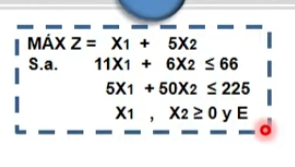

## Método Símplex

In [4]:
import numpy as np
from scipy.optimize import linprog

# Coeficientes de la función objetivo (negativos para maximizar)
# Z = 1*X1 + 5*X2
c = [-1, -5]

# Matriz de restricciones de desigualdad (izquierda)
A = [[11, 6], 
     [5, 50]]

# Vector de resultados de las restricciones (derecha)
b = [66, 225]

# Límites: X1 y X2 >= 0
x_bounds = (0, None)
y_bounds = (0, None)

# Resolver usando el método 'highs' (el más moderno y rápido)
res = linprog(c, A_ub=A, b_ub=b, bounds=[x_bounds, y_bounds], method='highs')

print("--- RESULTADOS ---")
print(f"X1 (Variable 1): {round(res.x[0], 2)}")
print(f"X2 (Variable 2): {round(res.x[1], 2)}")
print(f"Valor máximo de Z: {round(-res.fun, 2)}")

--- RESULTADOS ---
X1 (Variable 1): 3.75
X2 (Variable 2): 4.13
Valor máximo de Z: 24.37


## Programación Entera

In [5]:
import numpy as np
from scipy.optimize import linprog

# Z = 1*X1 + 5*X2 (negativo para maximizar)
c = [-1, -5]

# Restricciones
A = [[11, 6], [5, 50]]
b = [66, 225]

# Especificar que ambas variables (X1 y X2) deben ser ENTERAS
# 1 indica Entero, 0 indica Continuo
integrality = [1, 1] 

res = linprog(c, A_ub=A, b_ub=b, integrality=integrality, method='highs')

print("--- SOLUCIÓN ENTERA ÓPTIMA ---")
print(f"X1: {int(res.x[0])}")
print(f"X2: {int(res.x[1])}")
print(f"Z Máximo: {int(-res.fun)}")

--- SOLUCIÓN ENTERA ÓPTIMA ---
X1: 3
X2: 4
Z Máximo: 23


## Programación Entera (Branch & Bound)

In [6]:
import pulp

# 1. Definir el problema
prob = pulp.LpProblem("Ejercicio_Entero", pulp.LpMaximize)

# 2. Variables (Definidas como Integers)
x1 = pulp.LpVariable("X1", lowBound=0, cat='Integer')
x2 = pulp.LpVariable("X2", lowBound=0, cat='Integer')

# 3. Función Objetivo
prob += x1 + 5 * x2

# 4. Restricciones
prob += 11 * x1 + 6 * x2 <= 66
prob += 5 * x1 + 50 * x2 <= 225

# 5. Resolver mostrando el log del Branch & Bound
prob.solve(pulp.PULP_CBC_CMD(msg=True)) 

print(f"\nEstado: {pulp.LpStatus[prob.status]}")
print(f"Resultado: X1={x1.varValue}, X2={x2.varValue}, Z={pulp.value(prob.objective)}")

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/gonz4gtr/Code/DISA-UNAB/SIID-2/.venv/lib/python3.14/site-packages/pulp/apis/../solverdir/cbc/linux/i64/cbc /tmp/ef602ae8405a497b8ab29b6cd3cf18c2-pulp.mps -max -timeMode elapsed -branch -printingOptions all -solution /tmp/ef602ae8405a497b8ab29b6cd3cf18c2-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 7 COLUMNS
At line 18 RHS
At line 21 BOUNDS
At line 24 ENDATA
Problem MODEL has 2 rows, 2 columns and 4 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 24.375 - 0.00 seconds
Cgl0004I processed model has 2 rows, 2 columns (2 integer (0 of which binary)) and 4 elements
Cutoff increment increased from 1e-05 to 0.9999
Cbc0012I Integer solution of -23 found by DiveCoefficient after 0 iterations and 0 nodes (0.00 seconds)
Cbc0001I Search completed - best objective -23, took 1 iterations and 0 no

## Programación Entera Mixta

In [7]:
import numpy as np
from scipy.optimize import linprog

# Coeficientes (negativos para maximizar)
c = [-1, -5]

# Restricciones
A = [[11, 6], [5, 50]]
b = [66, 225]

# Definimos la integridad:
# 0 = Continua (X2)
# 1 = Entera (X1)
# El orden debe coincidir con el de las variables en 'c'
integrality = [1, 0] 

res = linprog(c, A_ub=A, b_ub=b, integrality=integrality, method='highs')

print("--- RESULTADO MIXTO ---")
print(f"X1 (Entera): {res.x[0]}")
print(f"X2 (Continua): {res.x[1]:.4f}")
print(f"Z Máximo: {-res.fun:.4f}")

--- RESULTADO MIXTO ---
X1 (Entera): 3.0
X2 (Continua): 4.2000
Z Máximo: 24.0000
